# Santer & Poterjoy 2026 Likelihood Estimation LPF Experiments


In [1]:
import numpy as np 
import sys
sys.path.insert(0, '..')
import DAPyr as dap
import matplotlib.pyplot as plt
from importlib import reload
from scipy.stats import norm, cauchy

from DAPyr.MISC import rkhs_likelihood
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import kaleido

reload(dap)

np.set_printoptions(suppress=True)


In [2]:
poep = {'mu': 0, 'sigma': 2.0} 
uoep = {'mu': 0, 'sigma': 2.0} 

poep_gaus_cauchy = {'mu': 0, 'sigma': 2} 
uoep_cauchy = {'x0': 0, 'gamma': 1.34}
poep_cauchy = {'x0': 0, 'gamma': 1.34} 

uoep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}
poep_sd = {'mu1': -2.0, 'sigma1': 1, 'mu2': 2.0, 'sigma2':1, 'threshold': 0}


In [8]:
e_sd_kecd = dap.Expt('e_sd_kecd', {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 1,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_sd,
                       'prescribed_obs_err_params': poep,
                       'save_keest_pab':1,
                       'log_every': 2,
                       'Ne':80,
                       'T': 2000,
                       'use_kde': False,
                       'T_train': 100,
                       'nle_type': 5,
                       'nle_every': 100, 
                       'Neig': 50,
                       'knn_frac': 0.1,
                       'bw_dm': 'knn_adaptive',
                       'debug_nle_noDA': False})

e_name = 'e_sd_true'
e_sd_true = dap.copyExpt(e_sd_kecd)
e_sd_true.modExptName(e_name)
e_sd_true.modExpt({'expt_flag': 1,
                   'prescribed_obs_err_params': poep_sd,
                   'prescribed_obs_err': 1})

e_name = 'e_sd_gaus'
e_sd_gaus = dap.copyExpt(e_sd_kecd)
e_sd_gaus.modExptName(e_name)
e_sd_gaus.modExpt({'expt_flag': 1})


In [9]:
dap.runDA(e_sd_kecd)
#dap.runDA(e_sd_true)
#dap.runDA(e_sd_gaus)
e_sd_kecd.saveExpt()
#e_sd_true.saveExpt()
#e_sd_gaus.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 2.2493093513369162
DB: RMSE at time 2: 1.2538075507850095
DB: RMSE at time 4: 1.2711084703222857
DB: RMSE at time 6: 1.2226114912760637
DB: RMSE at time 8: 1.1550481280566065
DB: RMSE at time 10: 1.067782055406032
DB: RMSE at time 12: 0.9260964619122615
DB: RMSE at time 14: 0.8230337638727964
DB: RMSE at time 16: 0.7044865832725637
DB: RMSE at time 18: 0.7878407660066228
DB: RMSE at time 20: 0.7836577759914786
DB: RMSE at time 22: 0.7339490862705746
DB: RMSE at time 24: 0.6271387065736552
DB: RMSE at time 26: 0.6195149438406815
DB: RMSE at time 28: 0.7026226882236561
DB: RMSE at time 30: 0.7944530752067983
DB: RMSE at time 32: 0.7843112514508436
DB: RMSE at time 34: 0.7836927070408949
DB: RMSE at time 36: 0.7488884553964172
DB: RMSE at time 38: 0.9184129969640902
DB: RMSE at time 40: 0.9994850341540168
DB: RMSE at time 42: 0.9045087449990782
DB: RMSE at time 44: 0.9610813157092386
DB: RMSE at time 46: 0.9408691553047507
DB: RMSE at time 48: 0.9293901614345
DB: RMSE 

'completed'

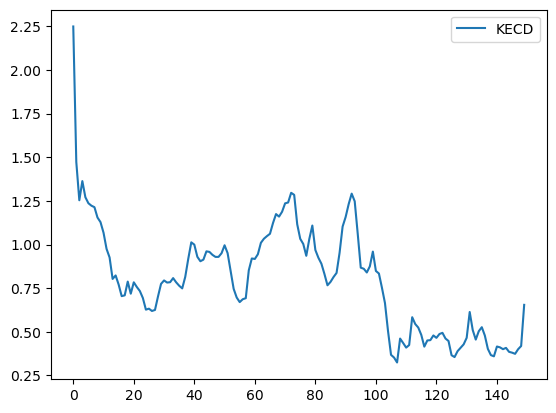

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment e_sd_kecd'}, xlabel='$y$', ylabel='$p(y | x)$'>

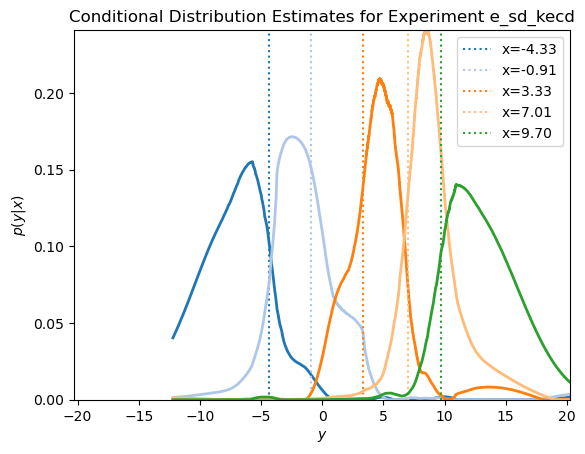

<Figure size 640x480 with 0 Axes>

In [11]:
plt.plot(e_sd_kecd.rmse, label='KECD')
#plt.plot(e_sd_true.rmse, label='True')
#plt.plot(e_sd_gaus.rmse, label='Gaussian')
plt.legend()
plt.show()
dap.plot_pab(e_sd_kecd, plot_states=True)

In [3]:
e_ch_kecd = dap.Expt('e_ch_kecd', {'expt_flag': 3,
                       'model_flag':2,
                       'localize':1,
                       'obf': 4,
                       'seed': 58,
                       'qc_flag': 0,
                       'used_obs_err': 3,
                       'prescribed_obs_err': 0,
                       'used_obs_err_params': uoep_cauchy,
                       'prescribed_obs_err_params': poep_gaus_cauchy,
                       'save_keest_pab':1,
                       'log_every': 50,
                       'Ne':80,
                       'T': 2000,
                       'T_train': 100,
                       'nle_type': 5,
                       'use_kde': False,
                       'nle_every': 100, 
                       'Neig': 50,
                       'knn_frac': 0.05,
                       'bw_dm': 'knn_adaptive',
                       'debug_nle_noDA': False})

#_name = 'e_ch_true'
#_ch_true = dap.copyExpt(e_ch_kecd)
#_ch_true.modExptName(e_name)
#_ch_true.modExpt({'expt_flag': 1,
#                  'prescribed_obs_err_params': poep_cauchy,
#                  'prescribed_obs_err': 3})

#_name = 'e_ch_gaus'
#_ch_gaus = dap.copyExpt(e_ch_kecd)
#_ch_gaus.modExptName(e_name)
#_ch_gaus.modExpt({'expt_flag': 1})


In [4]:
dap.runDA(e_ch_kecd)
e_ch_kecd.saveExpt()
#dap.runDA(e_ch_true)
#e_ch_true.saveExpt()
#dap.runDA(e_ch_gaus)
#e_ch_gaus.saveExpt()

/Users/etto/research/DAPyr-nle/src/notebooks/../DAPyr/DA.py:250: RuntimeWarning: divide by zero encountered in log
  dum = np.log(val)


DB: RMSE at time 0: 2.354828521904142
DB: RMSE at time 50: 0.8300664471474634
knn is: 600, number of samples = 12000
using median distance without 0s: 0.011906262956939747
knn is: 600, number of samples = 12000
using median distance without 0s: 1.49623595063195e-05
DB: RMSE at time 100: 0.8183026981567489


'completed'

0.42717389124292937
0.7031988634083088


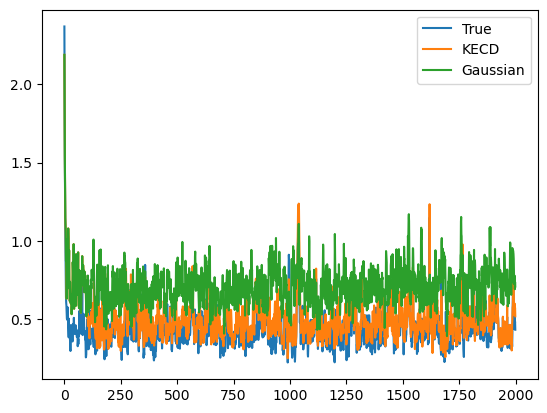

<Axes: title={'center': 'Conditional Distribution Estimates for Experiment e_ch_kecd'}, xlabel='$y$', ylabel='$p(y | x)$'>

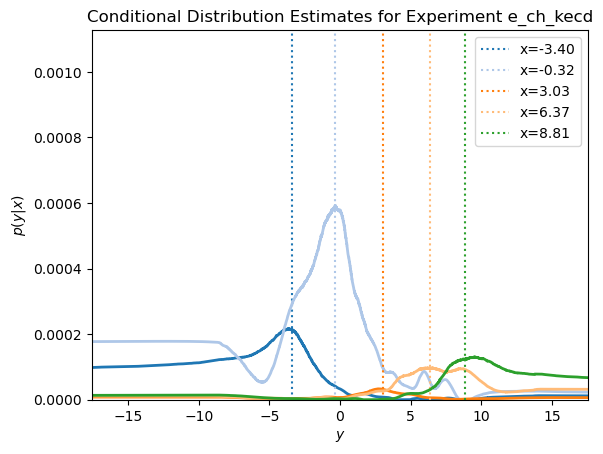

<Figure size 640x480 with 0 Axes>

In [7]:
e_ch_kecd2 = dap.loadExpt('e_ch_kecd.expt')
e_ch_true = dap.loadExpt('data/experiments/sp2026/e_ch_true.expt')
e_ch_gaus = dap.loadExpt('data/experiments/sp2026/e_ch_gaus.expt')
plt.plot(e_ch_true.rmse, label='True')
plt.plot(e_ch_kecd2.rmse, label='KECD')
plt.plot(e_ch_gaus.rmse, label='Gaussian')
print(e_ch_true.rmse[50:].mean())
print(e_ch_gaus.rmse[50:].mean())
#print(e_ch_kecd.rmse[50:].mean())
plt.legend()
plt.show()
dap.plot_pab(e_ch_kecd, plot_states=True)

In [57]:
def plot_pab(x_train, y_train, pab, plot_states=True, knn=0, bw=0):


      fig, ax = plt.subplots()
      ys = np.sort(y_train[0, :])
      ind2 = np.argsort(y_train[0, :])
      diff = np.diff(ys)

      cmap = plt.get_cmap('tab20')

      ax.set_title(f'knn, bw: {knn}, {bw}')

      htp = []

      states = np.quantile(x_train, [0.1, 0.25, 0.5, 0.75, 0.9])

      for ind, j in enumerate(states):
            dum = np.abs(j - x_train[0, :])
            ind1 = np.argsort(dum)[0]

            h = pab[ind2, ind1]

            # Normalize for plotting
            normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
            h_norm = h / normalization
            htp.append(h_norm)

            # Plotting
            ax.plot(ys, h_norm, linewidth=2, color=cmap(ind))
            if plot_states:
                  ax.axvline(x=j, color=cmap(ind), linestyle='dotted', label=f'x={j:.2f}')

      bound = max(np.abs(np.min(x_train)), np.abs(np.max(x_train)))
      ax.set_xlim([-bound, bound])
      ax.set_ylim([0, np.max(htp)])
      ax.legend()
      if ax is None:
            return fig, ax
      else:
            return ax


In [37]:
x_train.shape

(1, 12000)

In [133]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def plot_pab_given_states_plotly(x_train, y_train, pab, states):
    ys = np.sort(y_train[0, :])
    ind2 = np.argsort(y_train[0, :])
    diff = np.diff(ys)

    # Subplots: 1 row, 2 columns split evenly
    fig = make_subplots(
        rows=1, cols=2, 
        column_widths=[0.50, 0.50],
        subplot_titles=(
            'p(y | x) - Small Scale h(x)', 
            'RMSE - Small Scale h(x)'
        ),
        horizontal_spacing=0.08
    )

    # Original 4-color palette for states (left plot)
    states_palette = ['#0072B2', '#E69F00', '#009E73', '#CC79A7', '#000000']
    
    # Original color mapping for the right plot curves
    right_colors = {
        'True h(x)': '#000000', # Black
        'NoDA': '#D55E00',      # Vermillion / Orange-Red
        'KECD': '#56B4E9'       # Sky Blue
    }

    htp = []
    
    # Calculate global max for scaling the top threshold of vertical lines
    for i, state in enumerate(states):
        dists = np.sum((state - x_train.T)**2, axis=1)
        ind1 = np.argsort(dists)[0]
        h = pab[ind2, ind1]
        normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
        htp.append(h / normalization)
    
    y_max_limit = np.max(htp) * 1.05

    for i, state in enumerate(states):
        color = states_palette[i % len(states_palette)]
        h_norm = htp[i]
        
        # --- Plot Column 1: Probability Density ---
        fig.add_trace(
            go.Scatter(
                x=ys, 
                y=h_norm, 
                mode='lines', 
                line=dict(color=color, width=2.5),
                showlegend=False
            ),
            row=1, col=1
        )
        
        # --- Add Dotted Vertical Line at states[i] ---
        state_val = state[0] if isinstance(state, (np.ndarray, list)) else state
        
        fig.add_trace(
            go.Scatter(
                x=[state_val, state_val],
                y=[0, y_max_limit],
                mode='lines',
                name=f'x={state_val:.2f}',
                line=dict(color=color, width=1.5, dash='dot'),
                legend='legend1', 
                showlegend=True
            ),
            row=1, col=1
        )

    # --- Plot Column 2: RMSE Comparison ---
    fig.add_trace(
        go.Scatter(
            y=e_sd_true.rmse, 
            mode='lines', 
            name='True', 
            line=dict(color=right_colors['True h(x)'], width=2.5),
            legend='legend2', 
            showlegend=True
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(
            y=e_sd_gaus.rmse, 
            mode='lines', 
            name='Gaussian', 
            line=dict(color=right_colors['NoDA'], width=2.5),
            legend='legend2',
            showlegend=True
        ),
        row=1, col=2
    )
    fig.add_trace(
        go.Scatter(
            y=e_sd_kecd.rmse, 
            mode='lines', 
            name='KECD', 
            line=dict(color=right_colors['KECD'], width=2.5),
            legend='legend2',
            showlegend=True
        ),
        row=1, col=2
    )

    # --- Dual Legend Layout Adjustments ---
    fig.update_layout(
        template='plotly_white',
        height=500,
        width=1000,
        margin=dict(l=60, r=40, t=80, b=60, autoexpand=True),
        
        # Legend 1: Inside Left Figure
        legend=dict(
            orientation="v",
            yanchor="top",
            y=0.95,
            xanchor="left",
            x=0.01,  
            bgcolor="rgba(255, 255, 255, 0.8)",
            bordercolor="black",
            borderwidth=1
        ),
        
        # Legend 2: Inside Right Figure
        legend2=dict(
            orientation="v",
            yanchor="top",
            y=0.95,
            xanchor="left",
            x=0.55, 
            bgcolor="rgba(255, 255, 255, 0.8)",
            bordercolor="black",
            borderwidth=1
        )
    )

    # Axis Styling: Box frame with ticks ONLY on bottom and left
    axis_config = dict(
        showgrid=False,
        zeroline=False,
        showline=True,
        linewidth=1.5,
        linecolor='black',
        ticks='outside',
        tickwidth=1.5,
        tickcolor='black',
        mirror=True,
        automargin=True
    )

    # Apply configuration to all axes
    fig.update_xaxes(axis_config)
    fig.update_yaxes(axis_config)

    # --- Fixed Axis Specific Ranges & Labels ---
    # Column 1 (Probability Density)
    fig.update_xaxes(title_text='y', range=[-15, 20], row=1, col=1)
    fig.update_yaxes(
        title=dict(text='p(y | x)', standoff=2), 
        range=[0, y_max_limit], 
        row=1, col=1
    )
    
    # Column 2 (RMSE Comparison)
    fig.update_xaxes(title_text='Cycle #', range=[-100, 2100], row=1, col=2)
    fig.update_yaxes(
        title=dict(text='RMSE', standoff=2), 
        row=1, col=2
    )

    return fig

In [134]:
fig = plot_pab_given_states_plotly(e_sd_kecd.x_train, e_sd_kecd.y_train, e_sd_kecd.keest_pab, np.quantile(x_train, [0.1, 0.25, 0.5, 0.75, 0.9]))
fig.write_html('l05-sd.html')
fig.write_image('l05-sd.png', scale=2)